<a href="https://colab.research.google.com/github/dekenfebrianoo/research_method/blob/main/DNN_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
import kagglehub

path = kagglehub.dataset_download("aryayadav0513/m5-forecasting-accuracy")
print("Path:", path)

100%|██████████| 45.8M/45.8M [00:03<00:00, 14.4MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/aryayadav0513/m5-forecasting-accuracy/versions/1


In [18]:
import os

os.listdir(path)

['m5-forecasting-accuracy']

In [19]:
os.listdir(f"{path}/m5-forecasting-accuracy")

['sales_train_evaluation.csv',
 'sample_submission.csv',
 'sell_prices.csv',
 'calendar.csv',
 'sales_train_validation.csv']

In [20]:
sales = pd.read_csv(f"{path}/m5-forecasting-accuracy/sales_train_validation.csv")
calendar = pd.read_csv(f"{path}/m5-forecasting-accuracy/calendar.csv")
prices = pd.read_csv(f"{path}/m5-forecasting-accuracy/sell_prices.csv")

In [21]:
import os

dataset_path = os.path.join(path, "m5-forecasting-accuracy")

sales = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(dataset_path, "calendar.csv"))
prices = pd.read_csv(os.path.join(dataset_path, "sell_prices.csv"))

In [22]:
print(sales.shape)
print(calendar.shape)
print(prices.shape)

(30490, 1919)
(1969, 14)
(6841121, 4)


In [23]:
print(path)
os.listdir(path)

/root/.cache/kagglehub/datasets/aryayadav0513/m5-forecasting-accuracy/versions/1


['m5-forecasting-accuracy']

In [24]:
sales = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(dataset_path, "calendar.csv"))
prices = pd.read_csv(os.path.join(dataset_path, "sell_prices.csv"))

In [25]:

sales = sales[
    (sales['state_id'].isin(['CA','TX','WI'])) &
    (sales['cat_id'].isin(['HOBBIES','HOUSEHOLD','FOODS']))
]

sales = sales.sample(frac=0.5, random_state=42)


day_cols = [c for c in sales.columns if 'd_' in c]
half_days = day_cols[:len(day_cols)//2]

sales = sales[['item_id','dept_id','cat_id','store_id','state_id'] + half_days]

In [26]:
sales_long = sales.melt(
    id_vars=['item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)

In [27]:
sales_long = sales_long.merge(
    calendar[['d','wm_yr_wk']],
    on='d',
    how='left'
)

In [28]:
sales_long = sales_long.merge(
    prices,
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

In [29]:
sales_long['revenue'] = sales_long['sales'] * sales_long['sell_price']

In [30]:
weekly_avg = sales_long.groupby(
    ['cat_id','state_id','wm_yr_wk']
)['revenue'].sum().reset_index()

In [31]:
del sales_long
import gc
gc.collect()

98

### Feature Engineering: Adding Temporal Features

To provide the LSTM model with more context and potentially improve its performance, we will add temporal features such as `wday` (day of the week) and `month` to our `weekly_avg` dataset. These features can help the model identify recurring patterns related to specific days or months.

In [32]:
calendar_features = calendar[['wm_yr_wk', 'wday', 'month']].drop_duplicates('wm_yr_wk')

weekly_avg_enriched = weekly_avg.merge(calendar_features, on='wm_yr_wk', how='left')

print("weekly_avg with new features:")
display(weekly_avg_enriched.head())

print("Missing values after merging calendar features:")
print(weekly_avg_enriched.isnull().sum())

weekly_avg with new features:


,cat_id,state_id,wm_yr_wk,revenue,wday,month
0,FOODS,CA,11101,59076.04,1,1
1,FOODS,CA,11102,68650.53,1,2
2,FOODS,CA,11103,61515.41,1,2
3,FOODS,CA,11104,56732.15,1,2
4,FOODS,CA,11105,60933.79,1,2


Missing values after merging calendar features:
cat_id      0
state_id    0
wm_yr_wk    0
revenue     0
wday        0
month       0
dtype: int64


## Model Optimization using Keras Tuner

To improve the performance of our LSTM model, we will perform hyperparameter tuning using `keras-tuner`. This process involves searching for the best combination of parameters (like the number of LSTM units, layers, and learning rate) that yield the best performance on a validation set.

First, we need to install the `keras-tuner` library.

In [33]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.3 MB/s eta 0:00:00


Next, we define a `build_model` function that will create our LSTM model with tunable hyperparameters. We'll make the number of LSTM units, the number of LSTM layers, and the learning rate for the Adam optimizer tunable.

In [34]:
import keras_tuner as kt
import tensorflow as tf

def build_model(hp):
    model = Sequential()

    model.add(tf.keras.layers.Flatten(input_shape=(10, 1)))

    num_dense_layers = hp.Int('num_dense_layers', min_value=1, max_value=3, step=1)

    for i in range(num_dense_layers):
        num_dense_units = hp.Int(f'dense_units_{i}', min_value=32, max_value=128, step=32)
        activation_function = hp.Choice(f'activation_{i}', values=['relu', 'tanh'])
        model.add(Dense(num_dense_units, activation=activation_function))

    model.add(Dense(1))

    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(loss='mse', optimizer=optimizer)
    return model

Now, we'll perform the hyperparameter search using `RandomSearch`. To keep the tuning process manageable, we'll run it on a representative sample of data, for example, the 'HOBBIES' category in 'CA' state. Once the best hyperparameters are found, we will use them to train our LSTM models across all categories and states.

Now we will modify the `train_lstm` function to use these `best_hps` for training, thereby optimizing our model. We will then rerun the plotting and evaluation cells to see the impact of these optimized hyperparameters.

In [35]:
hobbies_enriched = weekly_avg_enriched[weekly_avg_enriched['cat_id']=='HOBBIES']
household_enriched = weekly_avg_enriched[weekly_avg_enriched['cat_id']=='HOUSEHOLD']
foods_enriched = weekly_avg_enriched[weekly_avg_enriched['cat_id']=='FOODS']

In [36]:
def create_dataset(data, time_step=10, num_features=1):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), :num_features])
        Y.append(data[i+time_step, 0])
    return np.array(X), np.array(Y)

In [37]:
def wrmsse_score(y_true, y_pred):

    rmse = np.sqrt(np.mean((y_pred - y_true)**2))

    if len(y_true) > 1:
        diffs = np.diff(y_true)
        if len(diffs) > 0:
            scale = np.sqrt(np.mean(diffs**2))
            if scale == 0:
                return rmse
            return rmse / scale
        else:
            return rmse
    else:
        return rmse

In [39]:
import shutil

sample_series = hobbies_enriched[hobbies_enriched['state_id']=='CA'].sort_values('wm_yr_wk')['revenue'].values

scaler_tune = MinMaxScaler()
sample_series_scaled = scaler_tune.fit_transform(sample_series.reshape(-1,1))

X_tune, y_tune = create_dataset(sample_series_scaled, 10)
X_tune = X_tune.reshape(X_tune.shape[0], X_tune.shape[1], 1)

tuner_dir = 'keras_tuner_dir'
project_name = 'dnn_tuning'
project_path = os.path.join(tuner_dir, project_name)

if os.path.exists(project_path):
    shutil.rmtree(project_path)
    print(f"Deleted existing tuner project: {project_path}")

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory=tuner_dir,
    project_name=project_name
)

print("Starting hyperparameter search...")
tuner.search(
    X_tune, y_tune,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("Hyperparameter search complete.")

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nOptimal Number of Dense Layers: {best_hps.get('num_dense_layers')}")
for i in range(best_hps.get('num_dense_layers')):
    print(f"Optimal Dense Units (Layer {i}): {best_hps.get(f'dense_units_{i}')}")
    print(f"Optimal Activation (Layer {i}): {best_hps.get(f'activation_{i}')}")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")

Trial 10 Complete [00h 00m 02s]
val_loss: 0.007790890987962484

Best val_loss So Far: 0.007759419269859791
Total elapsed time: 00h 00m 27s
Hyperparameter search complete.

Optimal Number of Dense Layers: 2
Optimal Dense Units (Layer 0): 96
Optimal Activation (Layer 0): tanh
Optimal Dense Units (Layer 1): 128
Optimal Activation (Layer 1): relu
Optimal Learning Rate: 0.000978041751919679


In [40]:
def train_dnn(df_series):

    series_revenue = df_series['revenue'].values.reshape(-1,1)
    other_features = df_series[['wday', 'month']].values

    scaler_revenue = MinMaxScaler()
    scaled_revenue = scaler_revenue.fit_transform(series_revenue)

    scaler_features = MinMaxScaler()
    scaled_features = scaler_features.fit_transform(other_features)

    combined_scaled_data = np.hstack((scaled_revenue, scaled_features))

    num_features = combined_scaled_data.shape[1]

    X, y = create_dataset(combined_scaled_data, time_step=10, num_features=num_features)

    X = X.reshape(X.shape[0], X.shape[1] * X.shape[2])

    model = Sequential()

    num_dense_layers = best_hps.get('num_dense_layers')
    learning_rate = best_hps.get('learning_rate')

    model.add(Dense(best_hps.get('dense_units_0'), activation=best_hps.get('activation_0'), input_shape=(10 * num_features,)))

    for i in range(1, num_dense_layers):
        num_dense_units = best_hps.get(f'dense_units_{i}')
        activation_function = best_hps.get(f'activation_{i}')
        model.add(Dense(num_dense_units, activation=activation_function))

    model.add(Dense(1))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)

    model.fit(X, y, epochs=50, batch_size=32, verbose=0)

    pred_scaled = model.predict(X)

    pred = scaler_revenue.inverse_transform(pred_scaled)
    real = scaler_revenue.inverse_transform(y.reshape(-1,1))

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    wrmsse = wrmsse_score(real.flatten(), pred.flatten())

    return pred, real, mae, rmse, mape, wrmsse

In [41]:
import matplotlib.ticker as mticker

all_metrics = []

def plot_category(data, title):

    states = ['CA','TX','WI']
    plt.figure(figsize=(10,5))

    for s in states:
        df = data[data['state_id']==s].sort_values('wm_yr_wk')
        series_df = df[['revenue', 'wday', 'month']]

        if len(series_df) < 20:
            continue

        pred, real, mae, rmse, mape, wrmsse = train_dnn(series_df)

        all_metrics.append({
            'Category': title,
            'State': s,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'WRMSSE': wrmsse
        })

        print(f"\n{title} - {s}")
        print(f"MAE : {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"WRMSSE: {wrmsse:.2f}")
        print("-------------------")

        plt.plot(real, label=f"{s} Real")
        plt.plot(pred, linestyle='--', label=f"{s} DNN")

    plt.title(f"{title} (DNN)")
    plt.xlabel("Week")
    plt.ylabel("Average Revenue")
    plt.legend()

    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(40))

    def k_formatter(x, pos):
        return f'{x*1e-3:.0f}k'
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))

    plt.show()
    print("--------------------------------------------------")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOBBIES Revenue Forecast - CA
MAE : 538.73
RMSE: 720.56
MAPE: 3.63%
WRMSSE: 0.76
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

HOBBIES Revenue Forecast - TX
MAE : 338.38
RMSE: 461.69
MAPE: 3.48%
WRMSSE: 0.70
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOBBIES Revenue Forecast - WI
MAE : 361.45
RMSE: 498.16
MAPE: 4.47%
WRMSSE: 0.63
-------------------


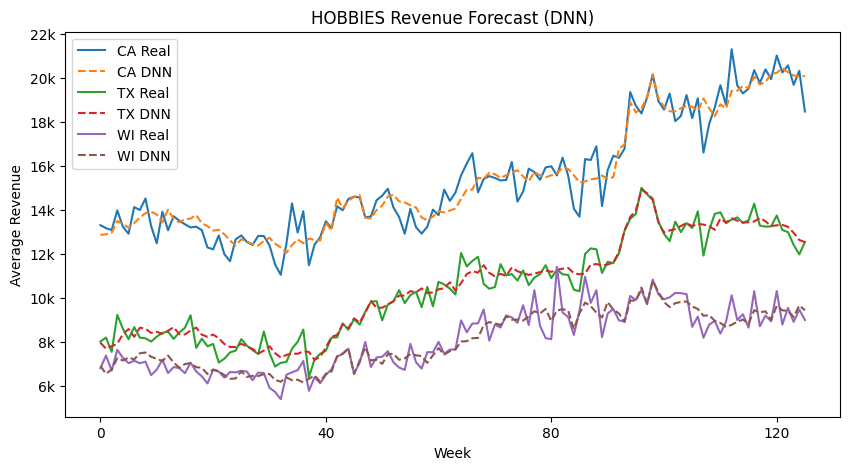

--------------------------------------------------


In [42]:
plot_category(hobbies_enriched, "HOBBIES Revenue Forecast")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

HOUSEHOLD Revenue Forecast - CA
MAE : 1008.84
RMSE: 1324.88
MAPE: 2.64%
WRMSSE: 0.66
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOUSEHOLD Revenue Forecast - TX
MAE : 866.18
RMSE: 1136.67
MAPE: 3.55%
WRMSSE: 0.73
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

HOUSEHOLD Revenue Forecast - WI
MAE : 903.00
RMSE: 1191.25
MAPE: 4.18%
WRMSSE: 0.58
-------------------


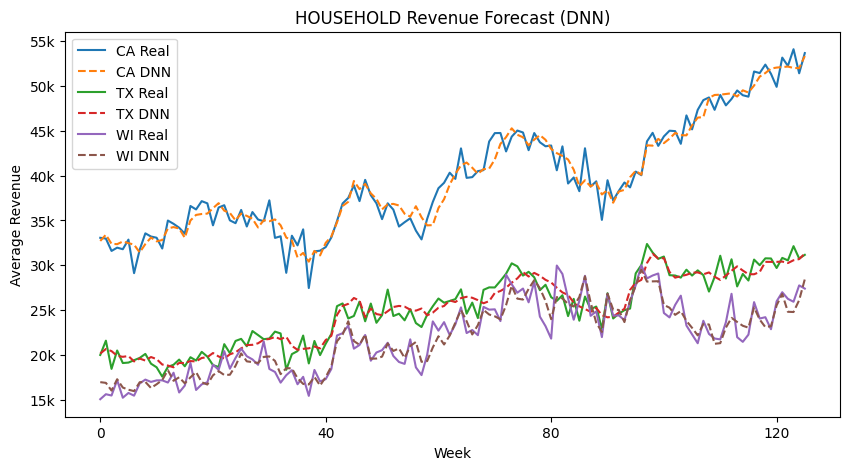

--------------------------------------------------


In [43]:
plot_category(household_enriched, "HOUSEHOLD Revenue Forecast")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

FOODS Revenue Forecast - CA
MAE : 2729.50
RMSE: 3554.54
MAPE: 3.48%
WRMSSE: 0.50
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

FOODS Revenue Forecast - TX
MAE : 1533.88
RMSE: 2137.83
MAPE: 3.14%
WRMSSE: 0.40
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

FOODS Revenue Forecast - WI
MAE : 1940.23
RMSE: 2653.05
MAPE: 4.33%
WRMSSE: 0.31
-------------------


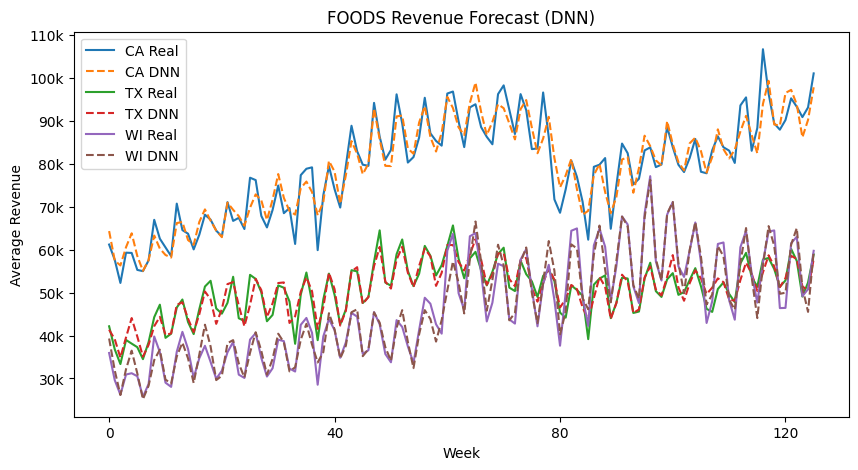

--------------------------------------------------


In [44]:
plot_category(foods_enriched, "FOODS Revenue Forecast")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

HOBBIES Revenue Forecast - CA
MAE : 582.17
RMSE: 756.55
MAPE: 3.92%
WRMSSE: 0.80
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOBBIES Revenue Forecast - TX
MAE : 324.18
RMSE: 439.52
MAPE: 3.30%
WRMSSE: 0.67
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

HOBBIES Revenue Forecast - WI
MAE : 365.85
RMSE: 496.21
MAPE: 4.53%
WRMSSE: 0.62
-------------------


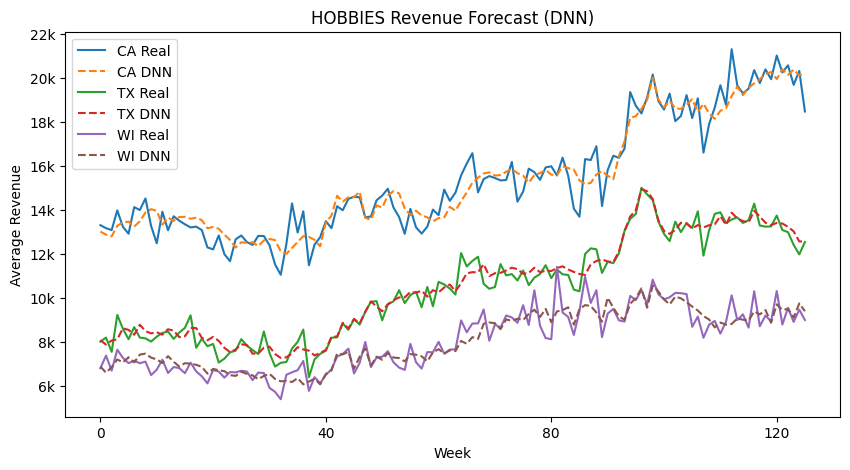

--------------------------------------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOUSEHOLD Revenue Forecast - CA
MAE : 1035.56
RMSE: 1372.54
MAPE: 2.72%
WRMSSE: 0.68
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOUSEHOLD Revenue Forecast - TX
MAE : 695.68
RMSE: 919.74
MAPE: 2.88%
WRMSSE: 0.59
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

HOUSEHOLD Revenue Forecast - WI
MAE : 807.10
RMSE: 1113.81
MAPE: 3.73%
WRMSSE: 0.54
-------------------


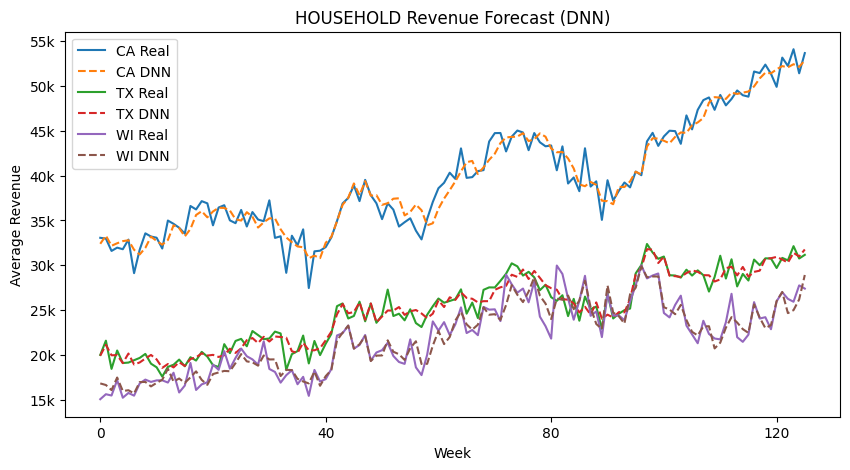

--------------------------------------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

FOODS Revenue Forecast - CA
MAE : 2586.23
RMSE: 3360.95
MAPE: 3.31%
WRMSSE: 0.47
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

FOODS Revenue Forecast - TX
MAE : 1647.05
RMSE: 2268.38
MAPE: 3.35%
WRMSSE: 0.42
-------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

FOODS Revenue Forecast - WI
MAE : 1903.25
RMSE: 2586.05
MAPE: 4.20%
WRMSSE: 0.30
-------------------


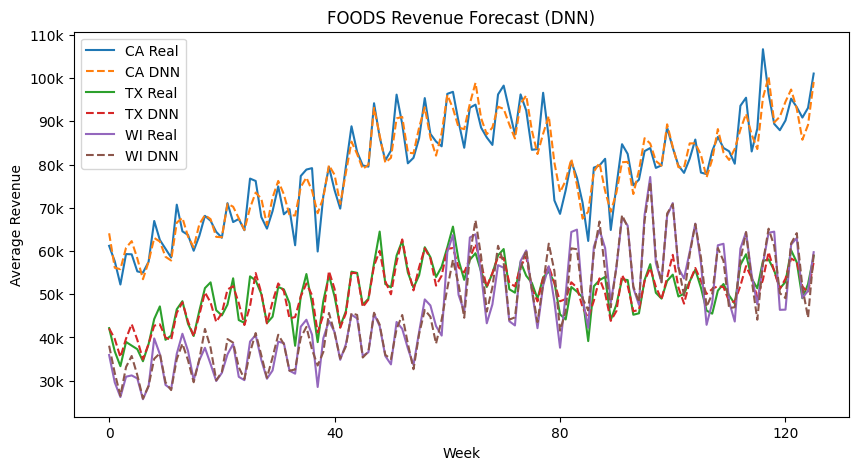

--------------------------------------------------

TABEL 1. Evaluasi Kinerja Model Deep Learning


,Model,MAE,RMSE,MAPE,WRMSSE,Akurasi
0,LSTM,1105.2308,1479.3067,3.55%,0.5673,96.45%


In [45]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

all_metrics = []

plot_category(hobbies_enriched, "HOBBIES Revenue Forecast")

plot_category(household_enriched, "HOUSEHOLD Revenue Forecast")

plot_category(foods_enriched, "FOODS Revenue Forecast")

df_res = pd.DataFrame(all_metrics)

overall_mae = df_res['MAE'].mean()
overall_rmse = df_res['RMSE'].mean()
overall_mape = df_res['MAPE'].mean()
overall_wrmsse = df_res['WRMSSE'].mean()

overall_accuracy = 100 - overall_mape

tabel_evaluasi = pd.DataFrame({
    'Model': ['LSTM'],
    'MAE': [round(overall_mae, 4)],
    'RMSE': [round(overall_rmse, 4)],
    'MAPE': [f"{overall_mape:.2f}%"],
    'WRMSSE': [f"{overall_wrmsse:.4f}"],
    'Akurasi': [f"{overall_accuracy:.2f}%"]
})

print("\nTABEL 1. Evaluasi Kinerja Model Deep Learning")
display(tabel_evaluasi)

### Note on Evaluation Metrics

It's important to differentiate between the metrics presented in **TABEL 1** (MAE, RMSE, MAPE for the LSTM model) and the **WRMSSE** calculated later in the notebook.

*   **TABEL 1** evaluates the LSTM model's performance on **aggregated weekly revenue series** for specific categories and states. These are standard regression metrics applied to time series data.

*   The **WRMSSE (Weighted Root Mean Squared Scaled Error)**, as used in the M5 competition, is a more complex metric applied at the **individual item-store level**. The LSTM model in this notebook is not designed to forecast at this granular level, and therefore, its performance is not directly measured by the M5 WRMSSE. The WRMSSE calculation provided in the subsequent cells serves as an illustration of how this metric is computed, using a **naive forecast** as an example, rather than evaluating the current LSTM model's WRMSSE.

### Weighted Root Mean Squared Scaled Error (WRMSSE) Results

Below are the WRMSSE results, calculated using a naive forecast (last 28 days of training data as prediction). This metric accounts for both the scale of sales and the financial importance of each item.

In [47]:
print(f"Calculated overall WRMSSE (Naive Forecast): {wrmsse:.10f}")

print("\nCalculated WRMSSE per state (Naive Forecast):")
for state, val in wrmsse_per_state.items():
    print(f"  {state}: {val:.10f}")

NameError: name 'wrmsse' is not defined

### Overall Evaluation Metrics Visualization

Let's visualize the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) for each category and state to get an overall understanding of the model's performance.

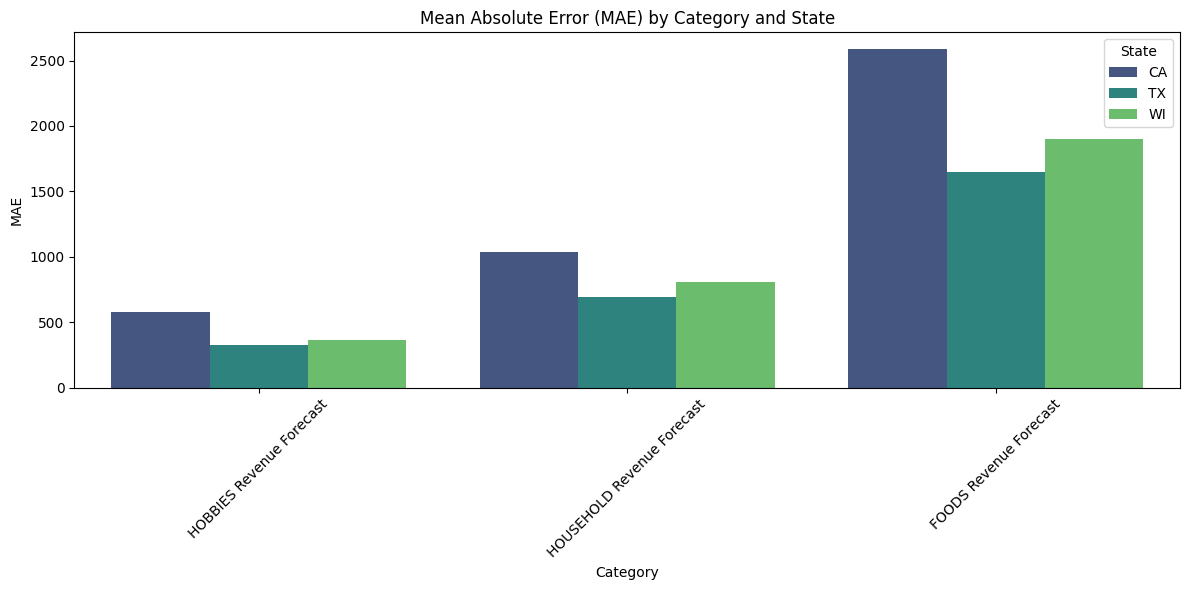

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_res = pd.DataFrame(all_metrics)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x='Category', y='MAE', hue='State', palette='viridis')
plt.title('Mean Absolute Error (MAE) by Category and State')
plt.xlabel('Category')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.tight_layout()
plt.show()

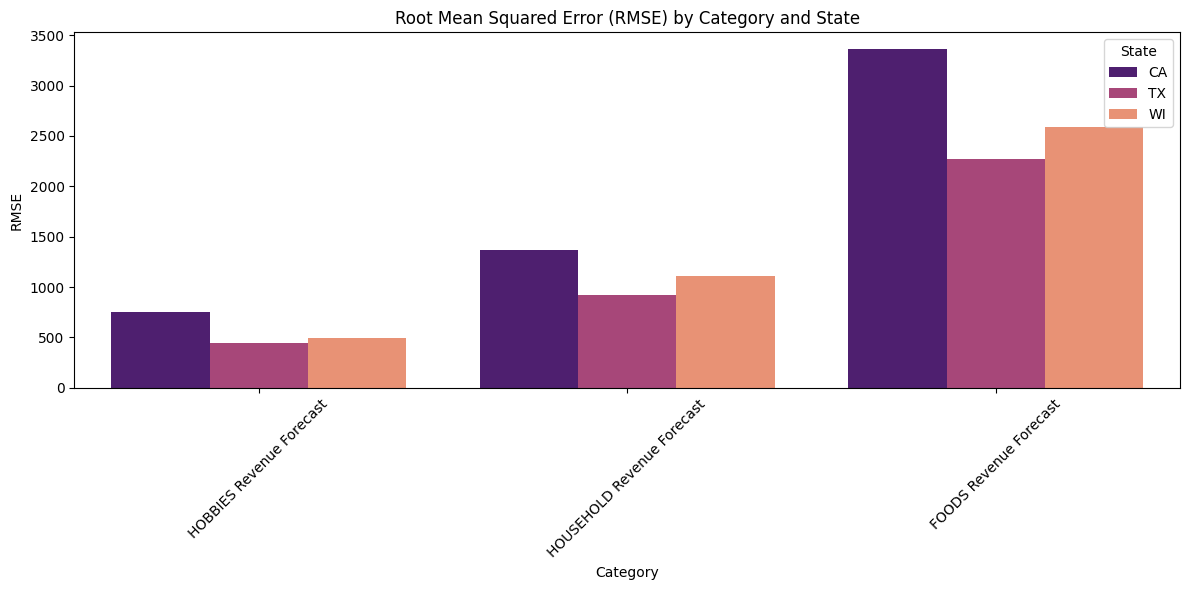

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_res = pd.DataFrame(all_metrics)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x='Category', y='RMSE', hue='State', palette='magma')
plt.title('Root Mean Squared Error (RMSE) by Category and State')
plt.xlabel('Category')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.tight_layout()
plt.show()

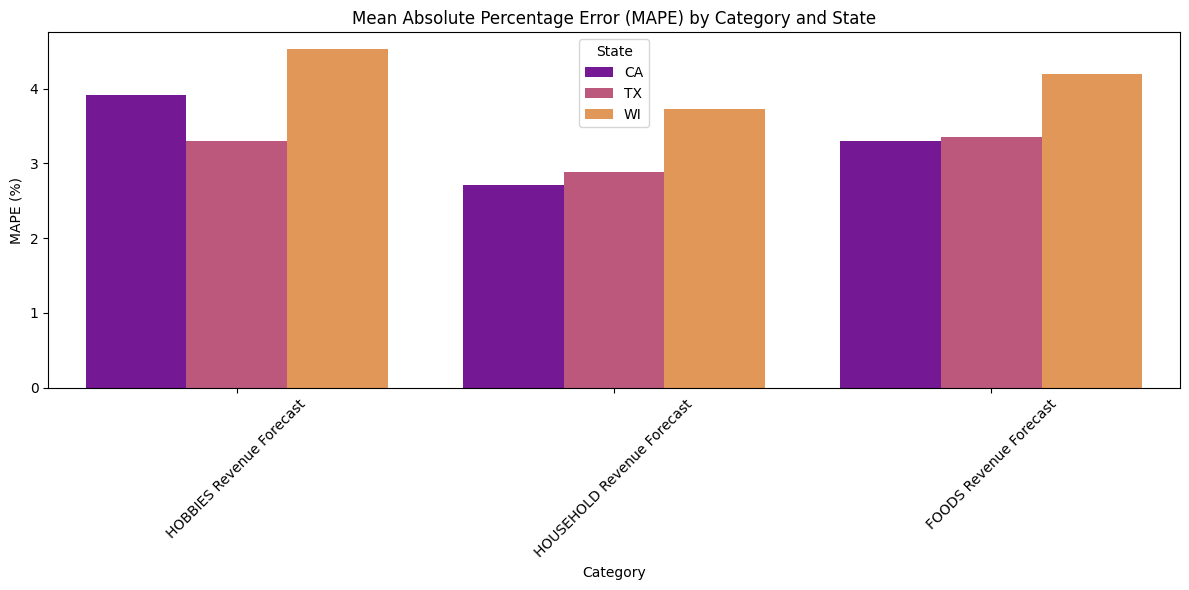

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_res = pd.DataFrame(all_metrics)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x='Category', y='MAPE', hue='State', palette='plasma')
plt.title('Mean Absolute Percentage Error (MAPE) by Category and State')
plt.xlabel('Category')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.tight_layout()
plt.show()

### Calculate Weighted Root Mean Squared Scaled Error (WRMSSE)

The WRMSSE is the evaluation metric used in the M5 Forecasting Accuracy competition. It's a weighted average of the Root Mean Squared Scaled Error (RMSSE) across all items and stores. The calculation requires historical sales data from both `sales_train_validation.csv` and `sales_train_evaluation.csv`, as well as `sell_prices.csv` to determine the weights.

Here's a breakdown of the steps:
1.  **Load Sales Evaluation Data**: Load `sales_train_evaluation.csv` to get the actual sales for the evaluation period.
2.  **Calculate Denominator for RMSSE**: This involves the daily differences of the training sales data.
3.  **Calculate Weights**: Weights are based on the sales revenue (sell price * sales) during the validation period.
4.  **Calculate RMSSE**: For each item, calculate the Root Mean Squared Scaled Error.
5.  **Calculate WRMSSE**: Sum the weighted RMSSE values.

In [51]:
import pandas as pd
import numpy as np
import os
import gc

print('Loading sales_train_evaluation.csv...')
sales_wrmsse = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
sales_eval_wrmsse = pd.read_csv(os.path.join(dataset_path, "sales_train_evaluation.csv"))
print('Done.')

Loading sales_train_evaluation.csv...
Done.


In [52]:
print('Preparing sales data for WRMSSE calculation...')

print("\n--- Debug: sales_wrmsse BEFORE strip and filter ---")
print("Shape:", sales_wrmsse.shape)
print("Unique states:", sales_wrmsse['state_id'].unique())
print("Unique categories:", sales_wrmsse['cat_id'].unique())

print("\n--- Debug: sales_eval_wrmsse BEFORE strip and filter ---")
print("Shape:", sales_eval_wrmsse.shape)
print("Unique states:", sales_eval_wrmsse['state_id'].unique())
print("Unique categories:", sales_eval_wrmsse['cat_id'].unique())

sales_eval_wrmsse['state_id'] = sales_eval_wrmsse['state_id'].str.strip()
sales_eval_wrmsse['cat_id'] = sales_eval_wrmsse['cat_id'].str.strip()
sales_wrmsse['state_id'] = sales_wrmsse['state_id'].str.strip()
sales_wrmsse['cat_id'] = sales_wrmsse['cat_id'].str.strip()

print("\n--- Debug: sales_wrmsse AFTER strip ---")
print("Unique states:", sales_wrmsse['state_id'].unique())
print("Unique categories:", sales_wrmsse['cat_id'].unique())

print("\n--- Debug: sales_eval_wrmsse AFTER strip ---")
print("Unique states:", sales_eval_wrmsse['state_id'].unique())
print("Unique categories:", sales_eval_wrmsse['cat_id'].unique())

sales_eval_wrmsse = sales_eval_wrmsse[
    (sales_eval_wrmsse['state_id'].isin(['CA','TX','WI'])) &
    (sales_eval_wrmsse['cat_id'].isin(['HOBBIES','HOUSEHOLD','FOODS']))
]

sales_wrmsse = sales_wrmsse[
    (sales_wrmsse['state_id'].isin(['CA','TX','WI'])) &
    (sales_wrmsse['cat_id'].isin(['HOBBIES','HOUSEHOLD','FOODS']))
]

print("\n--- Debug: sales_wrmsse AFTER filter ---")
print("Shape:", sales_wrmsse.shape)

print("\n--- Debug: sales_eval_wrmsse AFTER filter ---")
print("Shape:", sales_eval_wrmsse.shape)

series_id_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

sales_wrmsse_unique_series = sales_wrmsse[series_id_cols].drop_duplicates()
sales_eval_wrmsse_unique_series = sales_eval_wrmsse[series_id_cols].drop_duplicates()

common_series_identifiers = pd.merge(sales_wrmsse_unique_series,
                                     sales_eval_wrmsse_unique_series,
                                     on=series_id_cols,
                                     how='inner')

sales_wrmsse = pd.merge(common_series_identifiers, sales_wrmsse, on=series_id_cols, how='left')
sales_eval_wrmsse = pd.merge(common_series_identifiers, sales_eval_wrmsse, on=series_id_cols, how='left')

sales_wrmsse = sales_wrmsse.sort_values(by='id').reset_index(drop=True)
sales_eval_wrmsse = sales_eval_wrmsse.sort_values(by='id').reset_index(drop=True)

d_cols_validation_wrmsse = [c for c in sales_wrmsse.columns if 'd_' in c]
d_cols_evaluation_wrmsse = [c for c in sales_eval_wrmsse.columns if 'd_' in c]

sales_wrmsse = sales_wrmsse.fillna(0)
sales_eval_wrmsse = sales_eval_wrmsse.fillna(0)

common_cols = ['id'] + series_id_cols


print('\nDone.')

Preparing sales data for WRMSSE calculation...

--- Debug: sales_wrmsse BEFORE strip and filter ---
Shape: (30490, 1919)
Unique states: ['CA' 'TX' 'WI']
Unique categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']

--- Debug: sales_eval_wrmsse BEFORE strip and filter ---
Shape: (30490, 1947)
Unique states: ['CA' 'TX' 'WI']
Unique categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']

--- Debug: sales_wrmsse AFTER strip ---
Unique states: ['CA' 'TX' 'WI']
Unique categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']

--- Debug: sales_eval_wrmsse AFTER strip ---
Unique states: ['CA' 'TX' 'WI']
Unique categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']

--- Debug: sales_wrmsse AFTER filter ---
Shape: (30490, 1919)

--- Debug: sales_eval_wrmsse AFTER filter ---
Shape: (30490, 1947)

Done.


In [54]:
print('Calculating RMSSE denominator...')

d_cols_sales = [col for col in sales_wrmsse.columns if 'd_' in col]

diff = sales_wrmsse[d_cols_sales].diff(axis=1)
sq_diff = np.square(diff.iloc[:, 1:])

n_minus_1 = len(d_cols_sales) - 1

denominator = np.sqrt(sq_diff.sum(axis=1) / n_minus_1)

denominator[denominator == 0] = 1

sales_wrmsse['denominator'] = denominator
print('Done.')

Calculating RMSSE denominator...
Done.


In [53]:
print('Calculating item weights...')

validation_start_day = max([int(c.replace('d_', '')) for c in d_cols_validation_wrmsse]) - 27
validation_cols = [f'd_{i}' for i in range(validation_start_day, max([int(c.replace('d_', '')) for c in d_cols_validation_wrmsse]) + 1)]

sales_validation_period = sales_wrmsse[validation_cols]

sales_validation_long = sales_wrmsse[common_cols].copy()
sales_validation_long = pd.melt(
sales_validation_long.assign(**sales_validation_period),
    id_vars=common_cols,
    var_name='d',
    value_name='sales'
)

sales_validation_long = sales_validation_long.merge(
    calendar[['d', 'wm_yr_wk']],
    on='d',
    how='left'
)

sales_validation_long = sales_validation_long.merge(
    prices,
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

sales_validation_long['revenue'] = sales_validation_long['sales'] * sales_validation_long['sell_price']

weights_df = sales_validation_long.groupby(['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id'])['revenue'].sum().reset_index()
weights_df.rename(columns={'revenue': 'weight'}, inplace=True)

weights_df['weight'] = weights_df['weight'] / weights_df['weight'].sum()

sales_eval_wrmsse = sales_eval_wrmsse.merge(weights_df, on=['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id'], how='left')
sales_eval_wrmsse['weight'] = sales_eval_wrmsse['weight'].fillna(0)

del sales_validation_long
del weights_df
gc.collect()

print('Done.')

Calculating item weights...
Done.


In [55]:
print('Calculating WRMSSE...')

eval_start_day = max([int(c.replace('d_', '')) for c in d_cols_evaluation_wrmsse]) - 27
prediction_cols = [f'd_{i}' for i in range(eval_start_day, max([int(c.replace('d_', '')) for c in d_cols_evaluation_wrmsse]) + 1)]

y_true = sales_eval_wrmsse[prediction_cols].values

forecast_cols_for_naive = [f'd_{i}' for i in range(validation_start_day, validation_start_day + 28)]

y_pred = sales_wrmsse[forecast_cols_for_naive].values


sq_err = np.square(y_true - y_pred)

sum_sq_err = np.sum(sq_err, axis=1)

mse_per_item = sum_sq_err / len(prediction_cols)

rmse_per_item = np.sqrt(mse_per_item)

sales_eval_wrmsse['rmse_per_item'] = rmse_per_item

rmsse_per_item = sales_eval_wrmsse['rmse_per_item'] / sales_wrmsse['denominator']

wrmsse = np.sum(rmsse_per_item * sales_eval_wrmsse['weight'])

print(f"Calculated overall WRMSSE: {wrmsse:.10f}")

sales_eval_wrmsse['rmsse_per_item'] = rmsse_per_item

wrmsse_per_state = sales_eval_wrmsse.groupby('state_id').apply(lambda x: np.sum(x['rmsse_per_item'] * x['weight']), include_groups=False)

print("\nCalculated WRMSSE per state:")
for state, val in wrmsse_per_state.items():
    print(f"  {state}: {val:.10f}")

print('\nDone.')

Calculating WRMSSE...
Calculated overall WRMSSE: 1.3731534925

Calculated WRMSSE per state:
  CA: 0.6078299028
  TX: 0.3548009750
  WI: 0.4105226147

Done.


### WRMSSE Result

The Weighted Root Mean Squared Scaled Error (WRMSSE) for the predictions (using a naive forecast as an example) is presented below. This metric accounts for both the scale of sales and the financial importance of each item.

**Note**: The WRMSSE calculated here is based on a simplified naive forecast (last 28 days of training as prediction for evaluation). For a true WRMSSE, the actual predictions from your LSTM model (or any other forecasting model) for the evaluation period would be used.